#### **Introduction**

Sales & Marketing department plays a key role in driving the company's sales and revenue growth. By analyzing historical sales transaction data, the company can uncover patterns in customer purchasing behavior that help identify opportunities to improve product promotion, optimize campaign timing, and focus efforts on high-performing markets.

#### **Business Questions**
##### Main Question:
What insights from the sales data can help the Sales and Marketing teams increase overall sales?

##### Sub Questions:
1. Which products generate the highest revenue?
2. What are the monthly and seasonal sales trends?
3. Which regions contribute the most to total sales?
4. Which product combinations are frequently purchased together?

#### **Data Source**
The dataset used in this analysis was obtained from Kaggle. It is publicly available and intended for exploratory data analysis practice.

Dataset: **Practice EDA on this Sales Dataset** by Dhruv Kothari  
Source: https://www.kaggle.com/datasets/dhruvkothari19/practice-eda-on-this-sales-dataset

#### **Data Overview**
This dataset contains sales transaction records including product information, quantity ordered, item price, order date and time, and customer location details such as street, city, state, and zip code.

##### **Import Library & Read Data**

In [33]:
import pandas as pd

df = pd.read_csv('sales_cleaned_final.csv')

df.head(10)

,order_id,product,quantity_ordered,price_each,order_date,order_month,order_quarter,order_time,street,city,state,zip,sales
0,176558,USB-C Charging Cable,2,11.95,2019-04-19,4,Q2,08:46,917 1st St,Dallas,TX,75001,23.90
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07,4,Q2,22:30,682 Chestnut St,Boston,MA,2215,99.99
2,176560,Google Phone,1,600.00,2019-04-12,4,Q2,14:38,669 Spruce St,Los Angeles,CA,90001,600.00
3,176561,Wired Headphones,1,11.99,2019-04-30,4,Q2,09:27,333 8th St,Los Angeles,CA,90001,11.99
4,176562,USB-C Charging Cable,1,11.95,2019-04-29,4,Q2,13:03,381 Wilson St,San Francisco,CA,94016,11.95
5,176563,Bose SoundSport Headphones,1,99.99,2019-04-02,4,Q2,07:46,668 Center St,Seattle,WA,98101,99.99
6,176564,USB-C Charging Cable,1,11.95,2019-04-12,4,Q2,10:58,790 Ridge St,Atlanta,GA,30301,11.95
7,176565,Macbook Pro Laptop,1,1700.00,2019-04-24,4,Q2,10:38,915 Willow St,San Francisco,CA,94016,1700.00
8,176566,Wired Headphones,1,11.99,2019-04-08,4,Q2,14:05,83 7th St,Boston,MA,2215,11.99
9,176567,Google Phone,1,600.00,2019-04-18,4,Q2,17:18,444 7th St,Los Angeles,CA,90001,600.00


#### **Graph Styling**

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

def set_chart_style(font='Arial', title_size=16, label_size=14, tick_size=12):
    sns.set_style("white")
    plt.rcParams['font.family'] = font
    plt.rcParams['axes.titlesize'] = title_size
    plt.rcParams['axes.labelsize'] = label_size
    plt.rcParams['xtick.labelsize'] = tick_size
    plt.rcParams['ytick.labelsize'] = tick_size
    plt.rcParams['axes.titleweight'] = 'bold'

#### **Exploratory Data Analysis** 

##### Which top 10 products generate the highest revenue?

To answer this question, we need to calculate the total revenue first.

In [48]:
df['revenue'] = df['quantity_ordered'] * df['price_each']

df = df[['order_id', 'product', 'quantity_ordered', 'price_each', 'revenue', 'order_date', 'order_month', 'order_quarter', 'order_time', 'street', 'city', 'state', 'zip','sales']]

df

,order_id,product,quantity_ordered,price_each,revenue,order_date,order_month,order_quarter,order_time,street,city,state,zip,sales
0,176558,USB-C Charging Cable,2,11.95,23.90,2019-04-19,4,Q2,08:46,917 1st St,Dallas,TX,75001,23.90
1,176559,Bose SoundSport Headphones,1,99.99,99.99,2019-04-07,4,Q2,22:30,682 Chestnut St,Boston,MA,2215,99.99
2,176560,Google Phone,1,600.00,600.00,2019-04-12,4,Q2,14:38,669 Spruce St,Los Angeles,CA,90001,600.00
3,176561,Wired Headphones,1,11.99,11.99,2019-04-30,4,Q2,09:27,333 8th St,Los Angeles,CA,90001,11.99
4,176562,USB-C Charging Cable,1,11.95,11.95,2019-04-29,4,Q2,13:03,381 Wilson St,San Francisco,CA,94016,11.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178432,259353,AAA Batteries (4-pack),3,2.99,8.97,2019-09-17,9,Q3,20:56,840 Highland St,Los Angeles,CA,90001,8.97
178433,259354,iPhone,1,700.00,700.00,2019-09-01,9,Q3,16:00,216 Dogwood St,San Francisco,CA,94016,700.00
178434,259355,iPhone,1,700.00,700.00,2019-09-23,9,Q3,07:39,220 12th St,San Francisco,CA,94016,700.00
178435,259356,34in Ultrawide Monitor,1,379.99,379.99,2019-09-19,9,Q3,17:30,511 Forest St,San Francisco,CA,94016,379.99


Then, for the visualization:

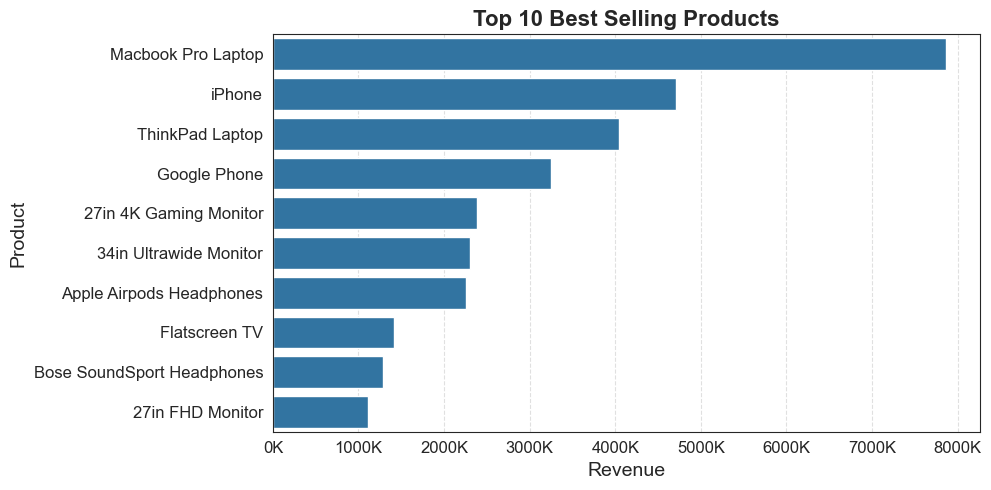

In [54]:
top_products = (df.groupby('product')['revenue'] 
                .sum() 
                .sort_values(ascending=False) 
                .head(10)
)

top_products_df = top_products.reset_index()
top_products_df.columns = ['Product', 'Revenue']

set_chart_style(font='Arial')
plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=top_products_df,
    y='Product',
    x='Revenue',
    orient='h'
)

plt.title('Top 10 Best Selling Products')
plt.xlabel('Revenue')
plt.ylabel('Product')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))

ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

Among the top 10 products, **MacBook Pro Laptop** generates significantly more revenue than the others, highlighting its dominant position. The X-axis shows revenue in K USD, while the Y-axis lists product names.

Graph Explanation

#### What are the monthly and seasonal sales trends?

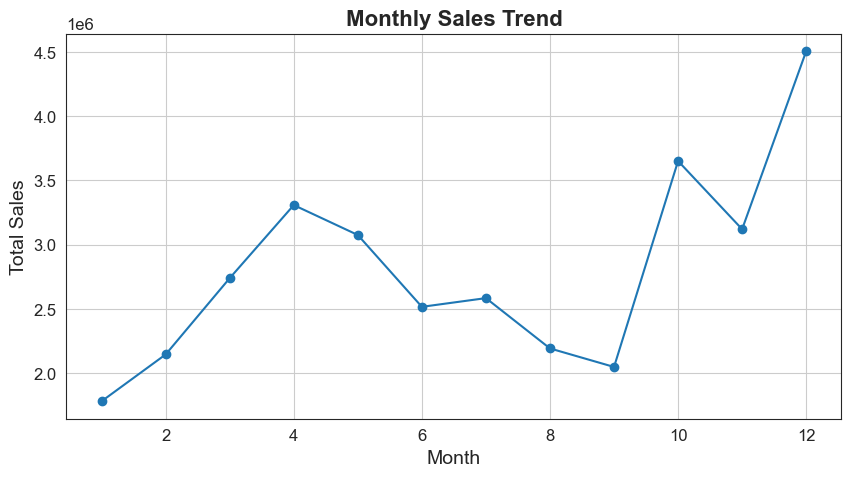

In [59]:
# Mengelompokkan data berdasarkan bulan (order_month)
# lalu menjumlahkan total sales pada setiap bulan
monthly_sales = df.groupby('order_month')['sales'].sum()

# Membuat ukuran grafik agar lebih besar dan mudah dibaca
plt.figure(figsize=(10,5))

# Membuat line chart untuk menunjukkan tren penjualan per bulan
# marker='o' menambahkan titik pada setiap data agar lebih jelas
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

# Menambahkan judul grafik
plt.title('Monthly Sales Trend')

# Memberi label pada sumbu X (bulan)
plt.xlabel('Month')

# Memberi label pada sumbu Y (total penjualan)
plt.ylabel('Total Sales')

# Menambahkan grid agar grafik lebih mudah dibaca
plt.grid(True)

# Menampilkan grafik
plt.show()

From the graph above, the monthly revenue trend peaks in December. Revenue gradually declines from April over the following months before rising again in October. January records the lowest revenue, reflecting the post-holiday slow period.

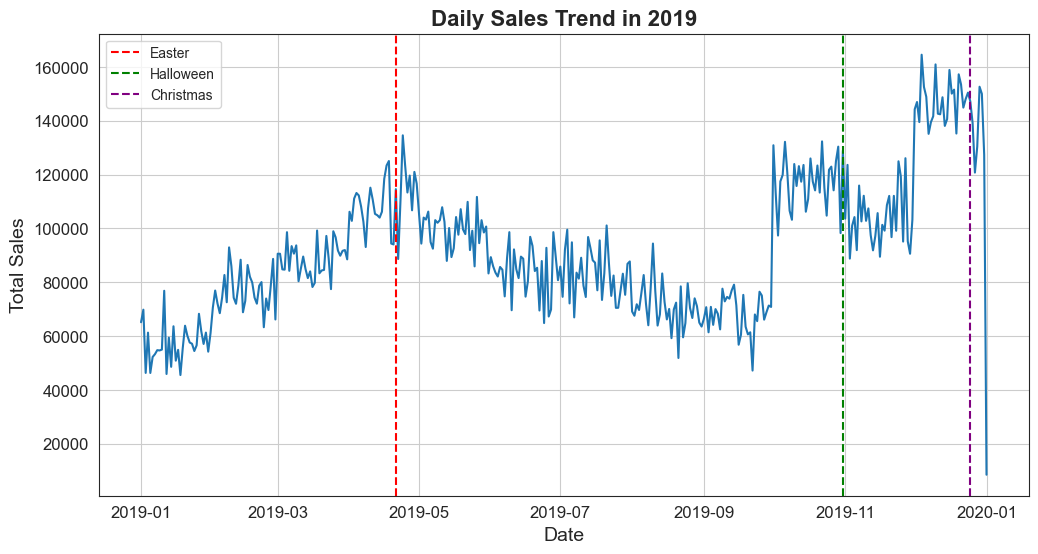

In [73]:
# pastikan format tanggal
df['order_date'] = pd.to_datetime(df['order_date'])

# hitung total sales per hari
daily_sales = df.groupby('order_date')['sales'].sum().reset_index()

plt.figure(figsize=(12,6))

plt.plot(daily_sales['order_date'], daily_sales['sales'])

plt.title('Daily Sales Trend in 2019')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.grid(True)

# tambahkan event besar
plt.axvline(pd.to_datetime('2019-04-21'), color='red', linestyle='--', label='Easter')
plt.axvline(pd.to_datetime('2019-10-31'), color='green', linestyle='--', label='Halloween')
plt.axvline(pd.to_datetime('2019-12-25'), color='purple', linestyle='--', label='Christmas')

plt.legend()

plt.show()

Sales increase around major seasonal events such as **Easter**, **Halloween**, and **Christmas**. Peaks occur near these periods, especially toward the end of the year and suggesting that holiday seasons likely drive higher consumer spending and overall sales.


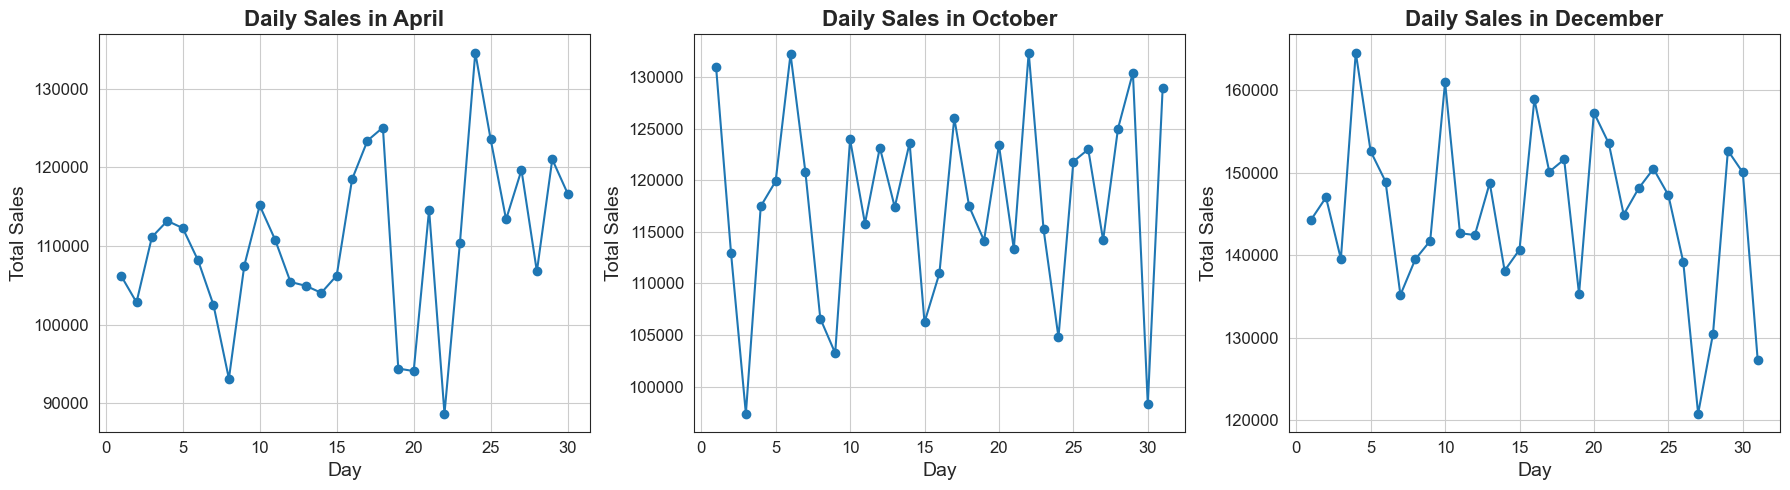

In [74]:
# Pastikan kolom tanggal dalam format datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Membuat kolom month dan day
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day

# Filter data hanya untuk April, October, December
top_months_df = df[df['month'].isin([4,10,12])]

# Hitung total sales per hari
daily_sales = top_months_df.groupby(['month','day'])['sales'].sum().reset_index()

# Membuat 3 subplot
fig, axes = plt.subplots(1, 3, figsize=(18,5))

months = {4:'April', 10:'October', 12:'December'}

for i, (month_num, month_name) in enumerate(months.items()):
    
    month_data = daily_sales[daily_sales['month'] == month_num]
    
    axes[i].plot(month_data['day'], month_data['sales'], marker='o')
    
    axes[i].set_title(f'Daily Sales in {month_name}')
    axes[i].set_xlabel('Day')
    axes[i].set_ylabel('Total Sales')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Daily sales fluctuate across **April, October, and December**, with several spikes on specific days. **December records the highest overall daily sales**, indicating stronger demand during the holiday season, while April and October display moderate peaks that may be influenced by seasonal shopping periods and promotional activities.


#### Which regions contribute the most to total revenue?

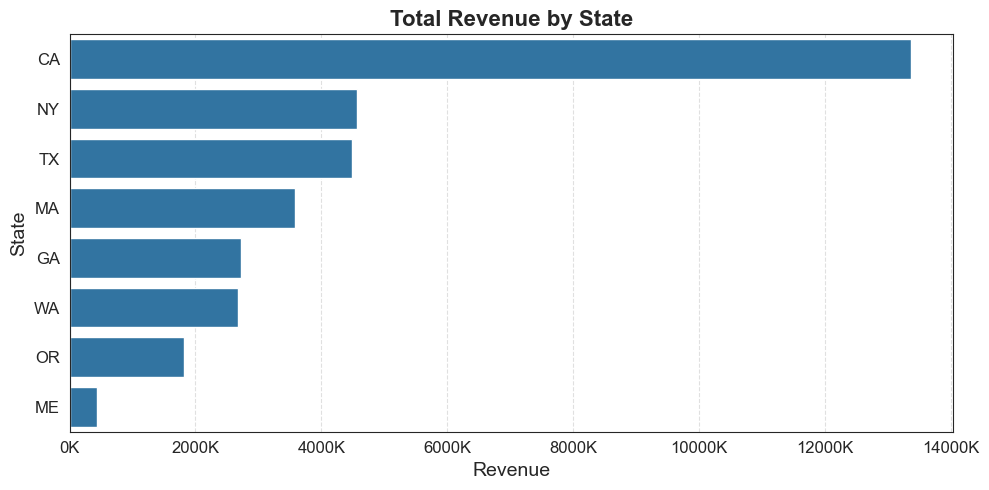

In [75]:
state_revenue = (df.groupby('state')['revenue'] 
                .sum() 
                .sort_values(ascending=False)
            )

state_revenue_df = state_revenue.reset_index()
state_revenue_df.columns = ['State', 'Revenue']

set_chart_style(font='Arial')
plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=state_revenue_df,
    x='Revenue',
    y='State'    
)

plt.title('Total Revenue by State')
plt.xlabel('Revenue')
plt.ylabel('State')

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.show()

Among all states, California (CA) generates significantly higher revenue compared to other states, indicating it is the dominant market. Other states follow, but there is a noticeable gap.

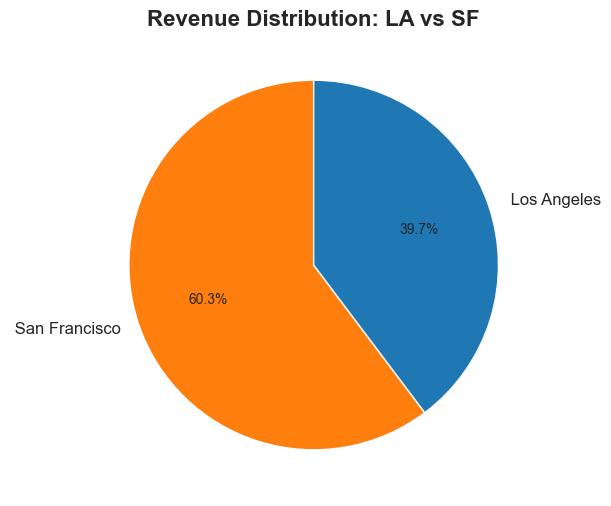

In [76]:
df_ca = df[df['state'].str.contains('CA', na=False)]

city_revenue_ca = df_ca.groupby('city')['revenue'].sum().sort_values(ascending=False)

set_chart_style(font='Arial')
plt.figure(figsize=(6,6))
colors = ['tab:orange', 'tab:blue']
plt.pie(
    city_revenue_ca,
    labels=city_revenue_ca.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
plt.title('Revenue Distribution: LA vs SF')
plt.show()

**San Francisco** dominates revenue in California, contributing 60.3% of the combined total of the top two cities, while Los Angeles accounts for 39.7%.

#### **Key Insights**

1. **MacBook Pro Laptop** generates significantly higher revenue than other products, indicating strong customer preference. **iPhone** and **ThinkPad Laptop** follow but with a noticeable gap, suggesting opportunity to boost mid-tier product** sales.

2. **Sales exhibit clear seasonality,** with **December recording the highest revenue** and **January the lowest.** Sales increase toward April, decline during the mid-year period, and rise sharply again in the final quarter.

3. Major seasonal events influence sales patterns, with noticeable increases around **Easter (April), Halloween (October), and Christmas (December),** suggesting that holiday periods drive higher consumer spending. **This indicates an opportunity for businesses to implement larger promotional campaigns or discounts during these periods to further boost sales and maximize revenue.**

4. **California contributes the most to total sales,** with** **San Francisco accounting for about 60.3%** of the combined revenue between the two cities, while **Los Angeles contributes the remaining 39.7%,** highlighting the strong market demand in this region.


#### **Conclusion**

Overall, the analysis indicates that sales performance is influenced by several key factors, including product demand, seasonal trends, and regional market strength. Premium products such as the **MacBook Pro** generate the highest revenue, highlighting strong customer preference for high-end electronics. Sales also display clear seasonal patterns, with noticeable increases during major holiday periods toward the end of the year. In terms of regional contribution, **California particularly San Francisco emerges as a major driver of total revenue**, reflecting strong market demand in this area. Together, these findings suggest that both seasonal events and regional dynamics play an important role in shaping overall sales performance and can be leveraged to optimize future sales strategies.
